In [36]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyacm import NominalACM

from build_moex_curve import build_moex_curve
from visualizations import plot_term_premium_comparison, plot_term_premium_decomposition


def tenor_columns(df: pd.DataFrame) -> list[str]:
    return sorted(
        [c for c in df.columns if re.fullmatch(r"M\d{3}", c)],
        key=lambda c: int(c[1:]),
    )


def build_month_end_curve_from_daily(daily_curve: pd.DataFrame) -> pd.DataFrame:
    cols = tenor_columns(daily_curve)
    ordered = daily_curve.copy()
    ordered["tradedate"] = pd.to_datetime(ordered["tradedate"])
    ordered = ordered.sort_values(["tradedate", "datetime"]).reset_index(drop=True)
    ordered["month"] = ordered["tradedate"].dt.to_period("M").astype(str)
    ordered["month_end"] = ordered["tradedate"].dt.to_period("M").dt.to_timestamp("M")
    month_end = ordered.groupby("month", as_index=False).last()
    return month_end[["month", "month_end", *cols]]


def build_monthly_median_curve_from_daily(daily_curve: pd.DataFrame) -> pd.DataFrame:
    cols = tenor_columns(daily_curve)
    ordered = daily_curve.copy()
    ordered["tradedate"] = pd.to_datetime(ordered["tradedate"])
    median_curve = (
        ordered.set_index("tradedate")[cols]
        .resample("ME")
        .median()
        .rename_axis("month_end")
        .reset_index()
    )
    median_curve["month"] = median_curve["month_end"].dt.to_period("M").astype(str)
    return median_curve[["month", "month_end", *cols]]


def to_pyacm_curve(curve_df: pd.DataFrame) -> pd.DataFrame:
    df = curve_df.copy()
    df["date"] = pd.to_datetime(df["month_end"])
    df = df.set_index("date").sort_index()

    curve_cols = tenor_columns(df)
    yield_curve = df[curve_cols].copy()
    yield_curve.columns = [int(c[1:]) for c in curve_cols]
    yield_curve = np.log1p(yield_curve / 100.0)
    yield_curve.index.name = "date"
    yield_curve.columns.name = "maturity_months"
    return yield_curve


def build_library_term_premium_frame(yield_curve: pd.DataFrame, acm: NominalACM) -> pd.DataFrame:
    months = sorted(set(yield_curve.columns) & set(acm.rny.columns) & set(acm.tp.columns))
    arrays = {"date": yield_curve.index}
    for month in months:
        arrays[f"obs_M{month:03d}"] = yield_curve[month].to_numpy(dtype=float) * 100.0
        arrays[f"rn_M{month:03d}"] = acm.rny[month].reindex(yield_curve.index).to_numpy(dtype=float) * 100.0
        arrays[f"tp_M{month:03d}"] = acm.tp[month].reindex(yield_curve.index).to_numpy(dtype=float) * 100.0
    return pd.DataFrame(arrays)


In [37]:
CLEAN_DIR = Path('.')
DEFAULT_DYNAMIC_PATH = CLEAN_DIR / "data" / "dynamic.csv"
DEFAULT_DAILY_OUTPUT = CLEAN_DIR / "output" / "moex_curve_daily.csv"
DEFAULT_MONTHLY_OUTPUT = CLEAN_DIR / "output" / "moex_curve_monthly.csv"
months = list(range(1, 361, 1))


daily_curve, monthly_curve = build_moex_curve(
    dynamic_path=DEFAULT_DYNAMIC_PATH,
    daily_output_path=DEFAULT_DAILY_OUTPUT,
    monthly_output_path=DEFAULT_MONTHLY_OUTPUT,
    months=months,
)

month_end_curve = build_month_end_curve_from_daily(daily_curve)
monthly_median_curve = build_monthly_median_curve_from_daily(daily_curve)

curve_versions = {
    "monthly_mean": monthly_curve,
    "month_end": month_end_curve,
    "monthly_median": monthly_median_curve,
}

pd.DataFrame(
    {
        "version": list(curve_versions.keys()),
        "n_obs": [len(df) for df in curve_versions.values()],
        "first_date": [pd.to_datetime(df["month_end"]).min() for df in curve_versions.values()],
        "last_date": [pd.to_datetime(df["month_end"]).max() for df in curve_versions.values()],
        "n_tenors": [len(tenor_columns(df)) for df in curve_versions.values()],
    }
)


,version,n_obs,first_date,last_date,n_tenors
0,monthly_mean,147,2014-01-31,2026-03-31,360
1,month_end,147,2014-01-31,2026-03-31,360
2,monthly_median,147,2014-01-31,2026-03-31,360


In [38]:
library_runs = {}

for name, curve_df in curve_versions.items():
    yield_curve = to_pyacm_curve(curve_df)
    acm = NominalACM(curve=yield_curve, n_factors=3)
    tp_frame = build_library_term_premium_frame(yield_curve=yield_curve, acm=acm)
    library_runs[name] = {
        "curve_df": curve_df,
        "yield_curve": yield_curve,
        "acm": acm,
        "tp": acm.tp,
        "rny": acm.rny,
        "miy": acm.miy,
        "tp_frame": tp_frame,
    }

pd.DataFrame(
    {
        "version": list(library_runs.keys()),
        "tp_24_last_pct": [run["tp_frame"]["tp_M024"].iloc[-1] for run in library_runs.values()],
        "tp_60_last_pct": [run["tp_frame"]["tp_M060"].iloc[-1] for run in library_runs.values()],
        "tp_120_last_pct": [run["tp_frame"]["tp_M120"].iloc[-1] for run in library_runs.values()],
    }
)


/Users/codebuller/Desktop/term_rate/.venv/lib/python3.9/site-packages/pyacm/acm.py:155: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.curve_monthly = curve.resample('M').mean()
/Users/codebuller/Desktop/term_rate/.venv/lib/python3.9/site-packages/pyacm/acm.py:155: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.curve_monthly = curve.resample('M').mean()
/Users/codebuller/Desktop/term_rate/.venv/lib/python3.9/site-packages/pyacm/acm.py:155: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.curve_monthly = curve.resample('M').mean()


,version,tp_24_last_pct,tp_60_last_pct,tp_120_last_pct
0,monthly_mean,0.285031,0.900891,1.578289
1,month_end,0.010455,0.804216,1.764675
2,monthly_median,0.276286,1.239640,1.938517


In [ ]:
# acm.pc_factors_m.to_csv('lib_scores.csv')
# acm.pc_loadings_m.to_csv('lib_loadings.csv')
acm.lambda0, acm.lambda1


(array([-0.01015291, -0.00475886,  0.05324482]),
 array([[-0.01100516,  0.01758622,  0.00221257],
        [-0.00595446, -0.10318781, -0.0083552 ],
        [ 0.02145545,  0.02501459, -0.07866596]]))

In [45]:
acm.rx_m

maturity_months,1,2,3,4,5,6,7,8,9,10,...,351,352,353,354,355,356,357,358,359,360
date,,,,,,,,,,,,,,,,,,,,,
2014-02-28,0,0.000006,-0.000018,-0.000046,-0.000099,-0.000181,-0.000289,-0.000419,-0.000594,-0.000798,...,0.019506,0.019684,0.019863,0.020043,0.020223,0.020403,0.020584,0.020765,0.020947,0.021129
2014-03-31,0,-0.000319,-0.000779,-0.001403,-0.001978,-0.002633,-0.003446,-0.004195,-0.004732,-0.005583,...,-0.143071,-0.143436,-0.143800,-0.144165,-0.144530,-0.144895,-0.145260,-0.145625,-0.145991,-0.146356
2014-04-30,0,0.000244,0.000504,0.000594,0.000666,0.000798,0.000749,0.000456,0.000454,0.000561,...,0.012865,0.013009,0.013152,0.013295,0.013437,0.013578,0.013718,0.013857,0.013996,0.014133
2014-05-31,0,-0.000072,-0.000291,-0.000571,-0.000737,-0.000947,-0.001316,-0.001726,-0.002188,-0.002662,...,0.103586,0.103933,0.104280,0.104627,0.104974,0.105321,0.105668,0.106015,0.106362,0.106709
2014-06-30,0,-0.000378,-0.000579,-0.000785,-0.000804,-0.000629,-0.000314,0.000089,0.000491,0.000739,...,0.069404,0.069492,0.069580,0.069669,0.069758,0.069848,0.069937,0.070028,0.070119,0.070210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,0,0.001883,0.003552,0.004871,0.005971,0.006879,0.007688,0.008537,0.009208,0.009695,...,0.212307,0.212893,0.213480,0.214066,0.214653,0.215240,0.215828,0.216415,0.217003,0.217591
2025-12-31,0,-0.000721,-0.001371,-0.001950,-0.002489,-0.002957,-0.003361,-0.003584,-0.003598,-0.003683,...,0.035404,0.035538,0.035671,0.035805,0.035938,0.036071,0.036204,0.036336,0.036468,0.036600
2026-01-31,0,-0.000162,-0.000308,-0.000411,-0.000508,-0.000597,-0.000726,-0.000859,-0.000998,-0.001146,...,-0.116977,-0.117368,-0.117758,-0.118149,-0.118539,-0.118930,-0.119320,-0.119710,-0.120100,-0.120490


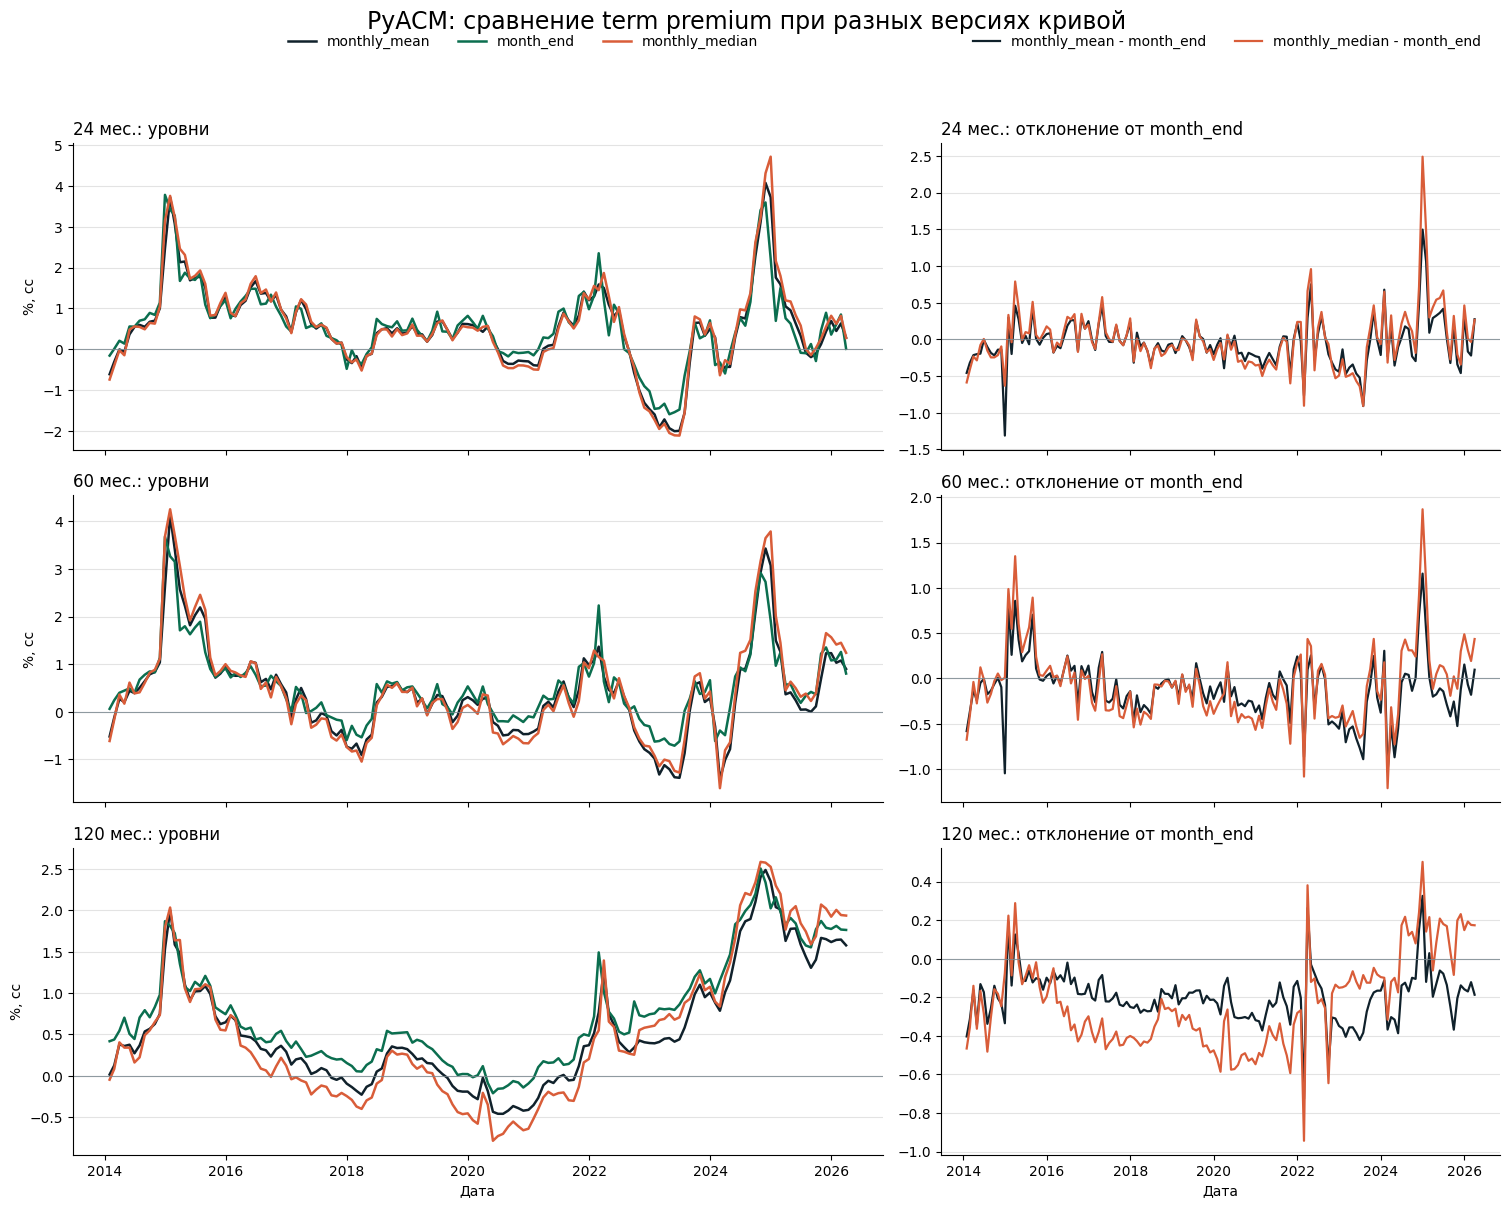

In [40]:
baseline_version = "month_end"
compare_frames = {name: run["tp"] for name, run in library_runs.items()}

fig, axes = plot_term_premium_comparison(
    versions=compare_frames,
    baseline=baseline_version,
    tenors=(24, 60, 120),
    title="PyACM: сравнение term premium при разных версиях кривой",
)
plt.show()


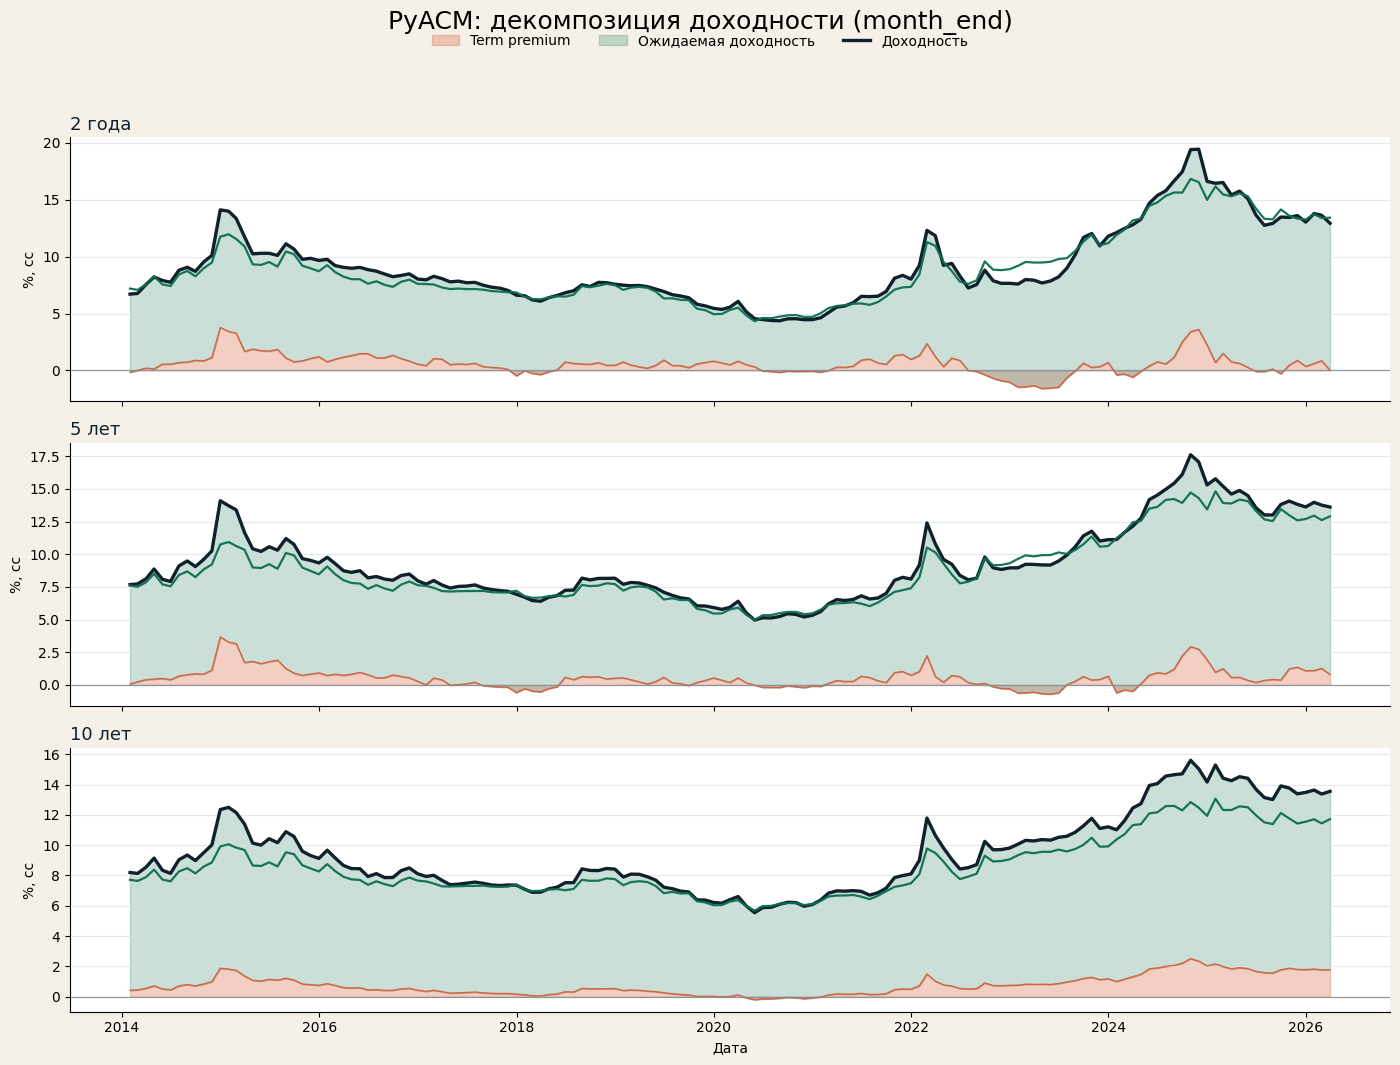

In [41]:
selected_version = "month_end"
selected_tp_frame = library_runs[selected_version]["tp_frame"]

fig, axes = plot_term_premium_decomposition(
    term_premium_df=selected_tp_frame,
    tenors={24: "2 года", 60: "5 лет", 120: "10 лет"},
    title=f"PyACM: декомпозиция доходности ({selected_version})",
)
plt.show()


In [42]:
comparison_summary = pd.DataFrame(
    [
        {
            "version": name,
            "tp_24_mean_pct": run["tp_frame"]["tp_M024"].mean(),
            "tp_60_mean_pct": run["tp_frame"]["tp_M060"].mean(),
            "tp_120_mean_pct": run["tp_frame"]["tp_M120"].mean(),
            "tp_24_std_pct": run["tp_frame"]["tp_M024"].std(ddof=0),
            "tp_60_std_pct": run["tp_frame"]["tp_M060"].std(ddof=0),
            "tp_120_std_pct": run["tp_frame"]["tp_M120"].std(ddof=0),
        }
        for name, run in library_runs.items()
    ]
)
comparison_summary


,version,tp_24_mean_pct,tp_60_mean_pct,tp_120_mean_pct,tp_24_std_pct,tp_60_std_pct,tp_120_std_pct
0,monthly_mean,0.526671,0.397800,0.554019,1.010290,0.955038,0.697513
1,month_end,0.573740,0.520175,0.751147,0.911058,0.765967,0.649249
2,monthly_median,0.564528,0.447758,0.525192,1.100617,1.064499,0.857923


In [43]:
for name, run in library_runs.items():
    run["tp"].to_csv(f"output/lib_tps_{name}.csv")

library_runs["month_end"]["tp"][60].tail()


date
2025-11-30    0.013535
2025-12-31    0.010792
2026-01-31    0.010991
2026-02-28    0.012590
2026-03-31    0.008042
Name: 60, dtype: float64